# Module Import

In [2]:
import pandas as pd
import numpy as np
from  matplotlib import pylab as plt

# Data Import

In [4]:
data = pd.read_csv("dataset.csv", encoding="latin1")

data

,sentiment,text
0,positive,"All banks, lending institutions may allow a th..."
1,neutral,"Not so fast, Drake..."
2,positive,FNF - ong 19.43. Trailing Stop 21.04 from 6 ...
3,positive,Dow opens down almost 500 points after China h...
4,positive,U.S. weekly active oil-rig count edges up by 1...
...,...,...
32578,negative,Airbnb to lose Â£325m in London bookings after...
32579,positive,Tesla surpasses 2019 goal and delivers 367500 ...
32580,positive,Hundreds of French workers at Caterpillar take...
32581,neutral,Emerging-economy central banks from India to B...


# NLP process

In [5]:
from transformers import pipeline

# Force the pipeline to use PyTorch ("pt")
nlp = pipeline("text-classification", model="ProsusAI/finbert", framework="pt")

# Analyze your sentences
sentences = data.iloc[:, 1].tolist()
results = nlp(sentences)

for result in results[:10]:
    print(result)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
Device set to use mps:0


ValueError: text input must be of type `str` (single example), `list[str]` (batch or single pretokenized example) or `list[list[str]]` (batch of pretokenized examples).

# Dianogsis

In [ ]:
result_labels = []
for result in results:
    result_labels.append(result['label'])
    
print(result_labels[:5])

['neutral', 'negative', 'positive', 'positive', 'positive']


## Accuracy Score:

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_true=data.iloc[:, 0], y_pred=result_labels)

0.8893704850361197

## Plots

<BarContainer object of 3 artists>

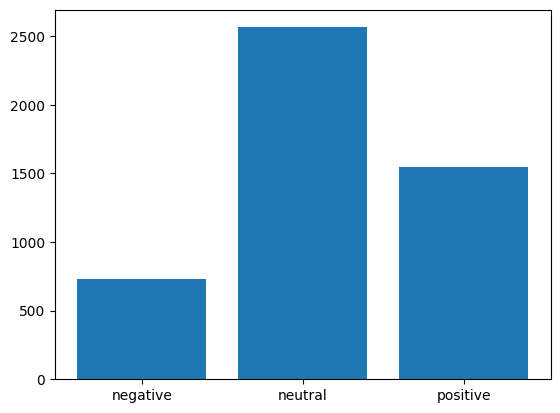

In [48]:
result_labels
x = np.unique(result_labels)

counts = np.unique(result_labels, return_counts=True)
height = []
for label in x:
    for idx, count in enumerate(counts[0]):
        if label == count:
            height.append(idx)
height = [counts[1][idx] for idx in height]
#height = np.log(height)

plt.bar(x, height, width=0.8, bottom=None, align='center')